In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
# load dataset
EnergySpotALL = pd.read_csv("EnergySpotAllData.csv")
EnergySpotALL.head()


,Date,// #,EPEX SPOT DA_DE/AUT (?/MWh),Sin(Hours),Cos(Hour),Sin(Day),Cos(Day),Transfercapacities X > BZN,Transfercapacities BZN > X,Carbon Price (EUSP),...,forecasted Load DE,Gen GER FC,Wind Gen DE FC,PV Gen DE FC,LoadFC-WindPVFC GER,Gen AUT FC,Gen FRA FC,Gen CZ FC,Load CZ FC,EXXA-Data
0,01.01.2015 00:00,0,25.02,0.000,1.000,-0.975,-0.223,9763,9963,7.2,...,35538.0,44992.0,NaN,0.0,NaN,3455.0,76550.0,7616,6568.0,25.98
1,01.01.2015 01:00,1,18.29,0.259,0.966,-0.975,-0.223,9763,9963,7.2,...,33556.0,44249.0,NaN,0.0,NaN,3274.0,75458.0,7676,6494.0,24.20
2,01.01.2015 02:00,2,16.04,0.500,0.866,-0.975,-0.223,9763,9963,7.2,...,31991.0,43099.0,NaN,0.0,NaN,3119.0,73688.0,7567,6375.0,22.55
3,01.01.2015 03:00,3,14.60,0.707,0.707,-0.975,-0.223,9763,9963,7.2,...,31435.0,41745.0,NaN,0.0,NaN,2994.0,72017.0,7279,6231.0,20.27
4,01.01.2015 04:00,4,14.95,0.866,0.500,-0.975,-0.223,9763,9963,7.2,...,31105.0,41474.0,NaN,0.0,NaN,2968.0,68956.0,6999,6171.0,19.17


In [2]:
# Drop rows with missing values
EnergySpotALL_new = EnergySpotALL.dropna()
# Rename column
EnergySpotALL_n = EnergySpotALL_new.rename(columns={'EPEX SPOT DA_DE/AUT (?/MWh)': 'EPEX_SPOT'})

In [3]:
EnergySpotValid = EnergySpotALL_n.drop(columns=['Date','// #'])

In [5]:
EnergySpotValid.head().reset_index(drop=False)

,index,EPEX_SPOT,Sin(Hours),Cos(Hour),Sin(Day),Cos(Day),Transfercapacities X > BZN,Transfercapacities BZN > X,Carbon Price (EUSP),Gas Price,...,forecasted Load DE,Gen GER FC,Wind Gen DE FC,PV Gen DE FC,LoadFC-WindPVFC GER,Gen AUT FC,Gen FRA FC,Gen CZ FC,Load CZ FC,EXXA-Data
0,48,-0.08,0.000,1.000,0.0,1.0,9718,9363,7.01,21.510,...,37610.0,42334.0,23817.0,0.0,13793,4533.0,73177.0,6827,6560.0,5.84
1,49,-0.07,0.259,0.966,0.0,1.0,9418,7544,7.01,20.599,...,34882.0,41316.0,24078.0,0.0,10804,4488.0,71207.0,6217,6379.0,0.19
2,50,-5.03,0.500,0.866,0.0,1.0,9418,7544,7.01,20.599,...,33425.0,40149.0,23388.0,0.0,10037,4152.0,69925.0,6144,6509.0,-1.66
3,51,0.01,0.707,0.707,0.0,1.0,9418,7544,7.01,20.599,...,33077.0,40478.0,22669.0,0.0,10408,4201.0,67426.0,6167,6467.0,-1.06
4,52,-0.04,0.866,0.500,0.0,1.0,9418,7544,7.01,20.599,...,33057.0,40431.0,21888.0,0.0,11169,4228.0,66922.0,6349,6534.0,1.86


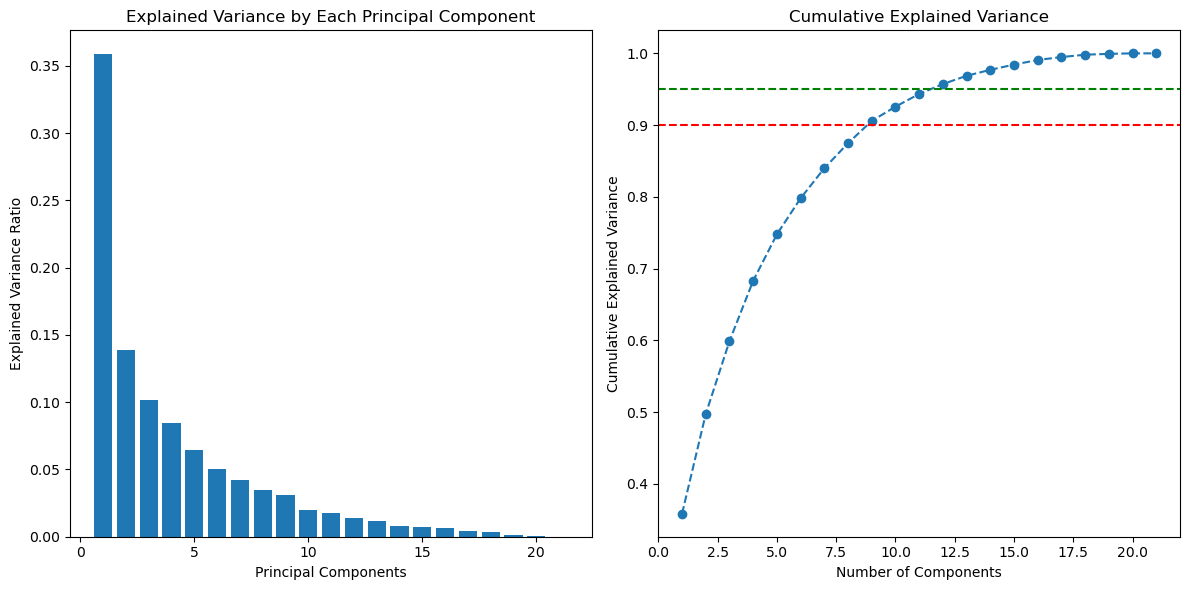

In [21]:
# FOR ONE HOUR, DELETE THE FEATURES OF Sin(Day)	Cos(Day)!!!

# Separate the target variable (EPEX_SPOT) and the features
X = EnergySpotValid.drop(columns=['EPEX_SPOT','Sin(Day)','Cos(Day)'])  # Features (excluding the target)
y = EnergySpotValid['EPEX_SPOT']  # Target variable

# 1. Standardize the features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 3. Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

# 4. Cumulative Explained Variance
cumulative_explained_variance = np.cumsum(explained_variance)

# 5. Plot Explained Variance and Cumulative Explained Variance
plt.figure(figsize=(12, 6))

# Plot Explained Variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Each Principal Component')

# Plot Cumulative Explained Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='--')  # Threshold for 90% variance
plt.axhline(y=0.95, color='g', linestyle='--')  # Threshold for 95% variance
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')

plt.tight_layout()
plt.show()



# 4. Visualize the explained variance ratio of the components
#print("Explained variance ratio:", pca.explained_variance_ratio_)

In [22]:
# 6. Check how many components explain at least 90% or 95% of the variance
n_components_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

print(f"Number of components explaining at least 90% variance: {n_components_90}")
print(f"Number of components explaining at least 95% variance: {n_components_95}")

Number of components explaining at least 90% variance: 9
Number of components explaining at least 95% variance: 12


In [23]:
# Apply PCA
pcaa = PCA(n_components=12)  # You can adjust the number of components based on your needs
X_pcaa = pcaa.fit_transform(X_scaled)

# 1. Principal Components (Loadings)
loadings = pcaa.components_

# Create a DataFrame to better interpret the loadings
loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])], index=X.columns)

# Display the loadings
print("Principal Component Loadings:")
print(loadings_df)


Principal Component Loadings:
                                 PC1       PC2       PC3       PC4       PC5  \
Sin(Hours)                 -0.103451 -0.135595  0.036175  0.053920  0.126317   
Cos(Hour)                  -0.155668 -0.375345  0.072780 -0.245678 -0.219444   
Transfercapacities X > BZN  0.099084 -0.137294  0.333771 -0.139957  0.458464   
Transfercapacities BZN > X  0.132640 -0.186413  0.259765 -0.030604  0.513367   
Carbon Price (EUSP)         0.036380 -0.149966  0.269294  0.553127 -0.165377   
Gas Price                   0.083627 -0.216078  0.213657  0.494911  0.039601   
Price Swissix               0.287274 -0.129523  0.105548 -0.039066 -0.219123   
PHELIX Futures Peak FP01    0.245563 -0.327195 -0.113074  0.092126 -0.068171   
PHELIX Futures Base FB01    0.230962 -0.340662 -0.195431  0.144309 -0.005420   
Holiday DE                 -0.076496  0.042553  0.127903 -0.026829  0.335232   
actual Load DE              0.318264  0.231750 -0.016175  0.003825 -0.108372   
forecasted

In [24]:
# 2. Explained Variance (Optional)
explained_variance = pcaa.explained_variance_ratio_
print("\nExplained Variance Ratio for each PC:")
print(explained_variance)



Explained Variance Ratio for each PC:
[0.35857259 0.1389349  0.10151355 0.08418335 0.06461832 0.0502733
 0.04184192 0.03490197 0.03100787 0.01982878 0.01772649 0.01380104]


In [25]:

# 3. Cumulative Explained Variance (Optional)
cumulative_explained_variance = np.cumsum(explained_variance)
print("\nCumulative Explained Variance:")
print(cumulative_explained_variance)


Cumulative Explained Variance:
[0.35857259 0.49750749 0.59902104 0.6832044  0.74782271 0.79809602
 0.83993794 0.87483991 0.90584778 0.92567656 0.94340305 0.95720409]


In [26]:
# Get the loadings for PC12 (index 11, as indexing starts from 0)
pc12_loadings = loadings[11]

# Create a DataFrame to easily view the loadings of each feature
loadings_df = pd.DataFrame(pc12_loadings, index=X.columns, columns=['PC12'])

# Get the top 12 features by absolute value of loadings for PC13
top_12_features = loadings_df.reindex(loadings_df['PC12'].abs().sort_values(ascending=False).index).head(12)

# Display the top 12 features
print("Top 12 features for PC12 based on absolute loadings:")
print(top_12_features)

Top 12 features for PC12 based on absolute loadings:
                                PC12
Gen GER FC                  0.484472
Price Swissix              -0.422038
Cos(Hour)                   0.408691
Transfercapacities BZN > X -0.339254
Transfercapacities X > BZN  0.333383
Gen AUT FC                  0.229090
Carbon Price (EUSP)         0.166649
PHELIX Futures Peak FP01    0.144883
PHELIX Futures Base FB01    0.142001
EXXA-Data                  -0.141456
Sin(Hours)                  0.138122
Holiday DE                  0.100516


In [27]:
X_EnergySpotValid=EnergySpotValid[['Sin(Hours)','Cos(Hour)','Sin(Day)','Cos(Day)','Carbon Price (EUSP)','Wind Gen DE FC','Gas Price','Transfercapacities BZN > X','PHELIX Futures Base FB01','Gen FRA FC','Gen CZ FC','forecasted Load DE ','actual Load DE','PV Gen DE FC','Gen GER FC','Price Swissix','Load CZ FC','EXXA-Data']]
y_EnergySpotValid=EnergySpotValid['EPEX_SPOT']

X_EnergySpotValid.head().reset_index(drop=False)

,index,Sin(Hours),Cos(Hour),Sin(Day),Cos(Day),Carbon Price (EUSP),Wind Gen DE FC,Gas Price,Transfercapacities BZN > X,PHELIX Futures Base FB01,Gen FRA FC,Gen CZ FC,forecasted Load DE,actual Load DE,PV Gen DE FC,Gen GER FC,Price Swissix,Load CZ FC,EXXA-Data
0,48,0.000,1.000,0.0,1.0,7.01,23817.0,21.510,9363,18.26,73177.0,6827,37610.0,44514.0,0.0,42334.0,39.48,6560.0,5.84
1,49,0.259,0.966,0.0,1.0,7.01,24078.0,20.599,7544,18.26,71207.0,6217,34882.0,42804.0,0.0,41316.0,37.01,6379.0,0.19
2,50,0.500,0.866,0.0,1.0,7.01,23388.0,20.599,7544,18.26,69925.0,6144,33425.0,41199.0,0.0,40149.0,35.61,6509.0,-1.66
3,51,0.707,0.707,0.0,1.0,7.01,22669.0,20.599,7544,18.26,67426.0,6167,33077.0,40274.0,0.0,40478.0,29.28,6467.0,-1.06
4,52,0.866,0.500,0.0,1.0,7.01,21888.0,20.599,7544,18.26,66922.0,6349,33057.0,39691.0,0.0,40431.0,26.24,6534.0,1.86


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [29]:
# Add the 'horizon' feature
X_next_hour = X.copy()
X_next_hour['horizon'] = 1  # Horizon = 1 for next-hour prediction
y_next_hour = y.copy()

X_24_hour = X.copy()
X_24_hour['horizon'] = 24  # Horizon = 24 for 24-hour prediction
y_24_hour = y.copy()

# Combine the datasets
X_combined = pd.concat([X_next_hour, X_24_hour], axis=0)
y_combined = pd.concat([y_next_hour, y_24_hour], axis=0)

In [30]:
print(X_combined)

       Sin(Hours)  Cos(Hour)  Transfercapacities X > BZN  \
48       0.000000   1.000000                        9718   
49       0.259000   0.966000                        9418   
50       0.500000   0.866000                        9418   
51       0.707000   0.707000                        9418   
52       0.866000   0.500000                        9418   
...           ...        ...                         ...   
17539   -0.965926   0.258819                       10618   
17540   -0.866025   0.500000                       10618   
17541   -0.707107   0.707107                       10618   
17542   -0.500000   0.866025                       10618   
17543   -0.258819   0.965926                       10618   

       Transfercapacities BZN > X  Carbon Price (EUSP)  Gas Price  \
48                           9363                 7.01     21.510   
49                           7544                 7.01     20.599   
50                           7544                 7.01     20.599   
51 

In [31]:
print(y_combined)

48       -0.08
49       -0.07
50       -5.03
51        0.01
52       -0.04
         ...  
17539    40.84
17540    35.05
17541    33.02
17542    33.71
17543    27.95
Name: EPEX_SPOT, Length: 33832, dtype: float64
